In [1]:
import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe solutions
mp_face_mesh = mp.solutions.face_mesh
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

In [4]:
# Initialize face mesh and hands
face_mesh = mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

hands = mp_hands.Hands(
    max_num_hands=2,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.5
)

print("MediaPipe models initialized!")

MediaPipe models initialized!


In [3]:
def process_frame(image):
    # Convert the BGR image to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Process face detection
    face_results = face_detection.process(image_rgb)
    
    # Process hand detection
    hand_results = hands.process(image_rgb)
    
    # Convert back to BGR for display
    annotated_image = image.copy()
    
    # Draw face detections
    if face_results.detections:
        for detection in face_results.detections:
            mp_drawing.draw_detection(annotated_image, detection)
    
    # Draw hand landmarks
    if hand_results.multi_hand_landmarks:
        for hand_landmarks in hand_results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                annotated_image,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS)
    
    return annotated_image

print("Processing function defined!")

Processing function defined!


In [6]:
def process_frame(image):
    # Convert the BGR image to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Process face mesh
    face_results = face_mesh.process(image_rgb)
    
    # Process hand detection
    hand_results = hands.process(image_rgb)
    
    # Convert back to BGR for display
    annotated_image = image.copy()
    
    # Draw face mesh
    if face_results.multi_face_landmarks:
        for face_landmarks in face_results.multi_face_landmarks:
            mp_drawing.draw_landmarks(
                image=annotated_image,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style()
            )
    
    # Draw hand landmarks
    if hand_results.multi_hand_landmarks:
        for hand_landmarks in hand_results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                image=annotated_image,
                landmark_list=hand_landmarks,
                connections=mp_hands.HAND_CONNECTIONS,
                landmark_drawing_spec=mp_drawing_styles.get_default_hand_landmarks_style(),
                connection_drawing_spec=mp_drawing_styles.get_default_hand_connections_style()
            )
    
    return annotated_image

print("Processing function defined!")

Processing function defined!


In [40]:
import cv2
import mediapipe as mp

# Initialize MediaPipe utilities
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh
mp_hands = mp.solutions.hands

# Initialize face_mesh and hands
face_mesh = mp_face_mesh.FaceMesh(max_num_faces=1, refine_landmarks=True, min_detection_confidence=0.5)
hands = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.5)

# Start video capture
cap = cv2.VideoCapture(0)

while cap.isOpened():
    success, image = cap.read()
    if not success:
        continue

    # Resize image to a target width while maintaining aspect ratio
    target_width = 640
    aspect_ratio = image.shape[1] / image.shape[0]
    target_height = int(target_width / aspect_ratio)
    image = cv2.resize(image, (target_width, target_height))
    
    # Flip the image horizontally and convert to RGB
    image = cv2.flip(image, 1)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Process face mesh
    face_results = face_mesh.process(image_rgb)
    
    # Process hands
    hand_results = hands.process(image_rgb)
    
    # Create a copy for annotation
    annotated_image = image.copy()
    
    # Draw face mesh
    if face_results.multi_face_landmarks:
        for face_landmarks in face_results.multi_face_landmarks:
            mp_drawing.draw_landmarks(
                image=annotated_image,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style()
            )
    
    # Draw hand landmarks
    if hand_results.multi_hand_landmarks:
        for hand_landmarks in hand_results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                image=annotated_image,
                landmark_list=hand_landmarks,
                connections=mp_hands.HAND_CONNECTIONS,
                landmark_drawing_spec=mp_drawing_styles.get_default_hand_landmarks_style(),
                connection_drawing_spec=mp_drawing_styles.get_default_hand_connections_style()
            )
    
    # Define landmark indices for eyes, nose, and mouth
    left_eye_indices = [33, 160, 158, 133, 153, 144, 33]  # Closed loop for left eye
    right_eye_indices = [362, 385, 387, 263, 373, 380, 362]  # Closed loop for right eye
    nose_indices = [240, 460]  # Dots for nostrils
    mouth_indices = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 61]  # Outer lip contour
    
    # Draw lines and dots for highlights
    if face_results.multi_face_landmarks:
        for face_landmarks in face_results.multi_face_landmarks:
            # Eyes: Red lines (thinner)
            for i in range(len(left_eye_indices) - 1):
                start_idx = left_eye_indices[i]
                end_idx = left_eye_indices[i + 1]
                start_landmark = face_landmarks.landmark[start_idx]
                end_landmark = face_landmarks.landmark[end_idx]
                start_x = int(start_landmark.x * annotated_image.shape[1])
                start_y = int(start_landmark.y * annotated_image.shape[0])
                end_x = int(end_landmark.x * annotated_image.shape[1])
                end_y = int(end_landmark.y * annotated_image.shape[0])
                cv2.line(annotated_image, (start_x, start_y), (end_x, end_y), (0, 0, 255), 2)  # Red, thickness 2
            for i in range(len(right_eye_indices) - 1):
                start_idx = right_eye_indices[i]
                end_idx = right_eye_indices[i + 1]
                start_landmark = face_landmarks.landmark[start_idx]
                end_landmark = face_landmarks.landmark[end_idx]
                start_x = int(start_landmark.x * annotated_image.shape[1])
                start_y = int(start_landmark.y * annotated_image.shape[0])
                end_x = int(end_landmark.x * annotated_image.shape[1])
                end_y = int(end_landmark.y * annotated_image.shape[0])
                cv2.line(annotated_image, (start_x, start_y), (end_x, end_y), (0, 0, 255), 2)  # Red, thickness 2
            
            # Nose: Green dots
            for idx in nose_indices:
                landmark = face_landmarks.landmark[idx]
                x = int(landmark.x * annotated_image.shape[1])
                y = int(landmark.y * annotated_image.shape[0])
                cv2.circle(annotated_image, (x, y), 5, (0, 255, 0), -1)  # Green, filled, radius 5
            
            # Mouth: Blue lines
            for i in range(len(mouth_indices) - 1):
                start_idx = mouth_indices[i]
                end_idx = mouth_indices[i + 1]
                start_landmark = face_landmarks.landmark[start_idx]
                end_landmark = face_landmarks.landmark[end_idx]
                start_x = int(start_landmark.x * annotated_image.shape[1])
                start_y = int(start_landmark.y * annotated_image.shape[0])
                end_x = int(end_landmark.x * annotated_image.shape[1])
                end_y = int(end_landmark.y * annotated_image.shape[0])
                cv2.line(annotated_image, (start_x, start_y), (end_x, end_y), (255, 0, 0), 3)  # Blue, thickness 3
    
    # Show the image
    cv2.imshow('MediaPipe Face Mesh and Hands', annotated_image)
    
    if cv2.waitKey(1) & 0xFF == 27:  # Press 'ESC' to exit
        break

cap.release()
cv2.destroyAllWindows()

print("Video capture completed!")

Video capture completed!


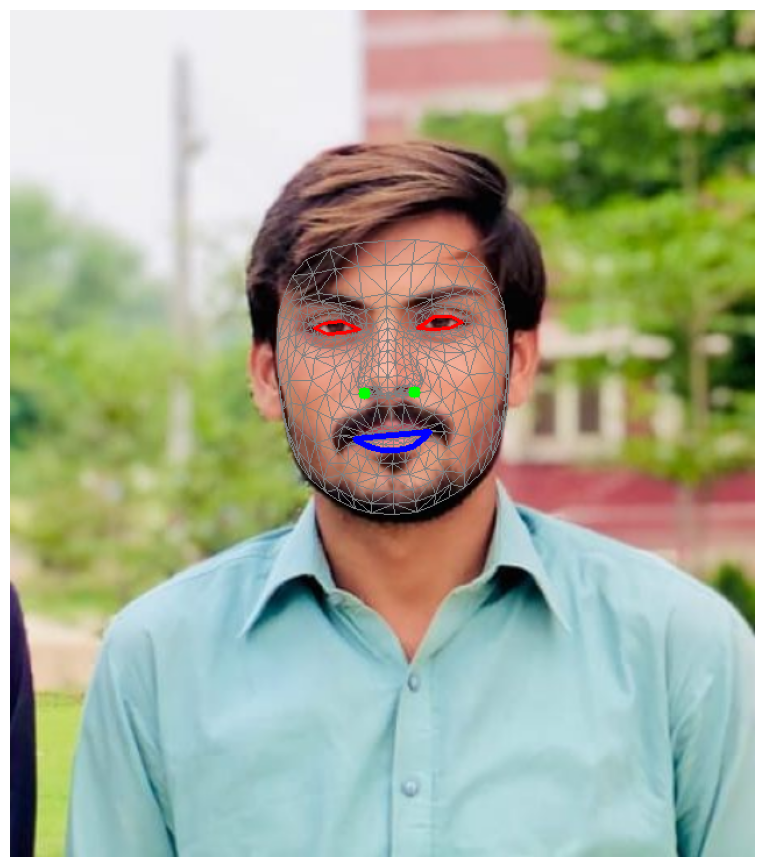

Image processing completed!


In [37]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import cv2
import mediapipe as mp

# Initialize MediaPipe utilities
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh
mp_hands = mp.solutions.hands

# Initialize face_mesh and hands
face_mesh = mp_face_mesh.FaceMesh(max_num_faces=1, refine_landmarks=True, min_detection_confidence=0.5)
hands = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.5)

# Load an image
image = cv2.imread('test_image.jpg')
if image is not None:
    # Resize image to a target width while maintaining aspect ratio
    target_width = 640
    aspect_ratio = image.shape[1] / image.shape[0]
    target_height = int(target_width / aspect_ratio)
    image = cv2.resize(image, (target_width, target_height))
    
    # Convert BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Process face mesh
    face_results = face_mesh.process(image_rgb)
    
    # Process hands
    hand_results = hands.process(image_rgb)
    
    # Create a copy for annotation
    annotated_image = image.copy()
    
    # Draw face mesh
    if face_results.multi_face_landmarks:
        for face_landmarks in face_results.multi_face_landmarks:
            mp_drawing.draw_landmarks(
                image=annotated_image,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style()
            )
    
    # Draw hand landmarks
    if hand_results.multi_hand_landmarks:
        for hand_landmarks in hand_results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                image=annotated_image,
                landmark_list=hand_landmarks,
                connections=mp_hands.HAND_CONNECTIONS,
                landmark_drawing_spec=mp_drawing_styles.get_default_hand_landmarks_style(),
                connection_drawing_spec=mp_drawing_styles.get_default_hand_connections_style()
            )
    
    # Define landmark indices for eyes, nose, and mouth
    left_eye_indices = [33, 160, 158, 133, 153, 144, 33]  # Closed loop for left eye
    right_eye_indices = [362, 385, 387, 263, 373, 380, 362]  # Closed loop for right eye
    nose_indices = [240, 460]  # Dots for nostrils
    mouth_indices = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 61]  # Outer lip contour
    
    # Draw lines and dots for highlights
    if face_results.multi_face_landmarks:
        for face_landmarks in face_results.multi_face_landmarks:
            # Eyes: Red lines (thinner)
            for i in range(len(left_eye_indices) - 1):
                start_idx = left_eye_indices[i]
                end_idx = left_eye_indices[i + 1]
                start_landmark = face_landmarks.landmark[start_idx]
                end_landmark = face_landmarks.landmark[end_idx]
                start_x = int(start_landmark.x * annotated_image.shape[1])
                start_y = int(start_landmark.y * annotated_image.shape[0])
                end_x = int(end_landmark.x * annotated_image.shape[1])
                end_y = int(end_landmark.y * annotated_image.shape[0])
                cv2.line(annotated_image, (start_x, start_y), (end_x, end_y), (0, 0, 255), 2)  # Red, thickness 2
            for i in range(len(right_eye_indices) - 1):
                start_idx = right_eye_indices[i]
                end_idx = right_eye_indices[i + 1]
                start_landmark = face_landmarks.landmark[start_idx]
                end_landmark = face_landmarks.landmark[end_idx]
                start_x = int(start_landmark.x * annotated_image.shape[1])
                start_y = int(start_landmark.y * annotated_image.shape[0])
                end_x = int(end_landmark.x * annotated_image.shape[1])
                end_y = int(end_landmark.y * annotated_image.shape[0])
                cv2.line(annotated_image, (start_x, start_y), (end_x, end_y), (0, 0, 255), 2)  # Red, thickness 2
            
            # Nose: Green dots
            for idx in nose_indices:
                landmark = face_landmarks.landmark[idx]
                x = int(landmark.x * annotated_image.shape[1])
                y = int(landmark.y * annotated_image.shape[0])
                cv2.circle(annotated_image, (x, y), 5, (0, 255, 0), -1)  # Green, filled, radius 5
            
            # Mouth: Blue lines
            for i in range(len(mouth_indices) - 1):
                start_idx = mouth_indices[i]
                end_idx = mouth_indices[i + 1]
                start_landmark = face_landmarks.landmark[start_idx]
                end_landmark = face_landmarks.landmark[end_idx]
                start_x = int(start_landmark.x * annotated_image.shape[1])
                start_y = int(start_landmark.y * annotated_image.shape[0])
                end_x = int(end_landmark.x * annotated_image.shape[1])
                end_y = int(end_landmark.y * annotated_image.shape[0])
                cv2.line(annotated_image, (start_x, start_y), (end_x, end_y), (255, 0, 0), 3)  # Blue, thickness 3
    
    # Convert BGR to RGB for display
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    
    # Display the image using matplotlib
    plt.figure(figsize=(10, int(10 / aspect_ratio)))  # Adjust figure size to match image aspect ratio
    plt.imshow(annotated_image_rgb)
    plt.axis('off')
    plt.show()

print("Image processing completed!")